In [1]:
# fix relative imports
import os
cwd = os.path.normpath(os.getcwd())
cwd = cwd.split(os.sep)
find = cwd.index("fidelity-phase-tran")
newdir = f"{os.sep}".join(cwd[:find+1])
os.chdir(newdir)

# import known packages
import numpy as np

from scipy.sparse import identity
import scipy.linalg as la
import scipy.sparse.linalg as spla

import matplotlib.pyplot as plt

from ncon import ncon

# import adhoc packages
from qs_mps.sparse_hamiltonians_and_operators import sparse_pauli_x, sparse_pauli_z
from qs_mps.utils import get_precision
from qs_mps.applications.ANNNI.ground_state_multiprocessing import ground_state_ANNNI
from qs_mps.mps_class import MPS

# Initialize ANNNI model for $h=0$

Let us find the best way to initialize the dmrg in the ground state search in the region  
where $h$ can be treated perturbatively ($h$ small).  
We have: 
- **Ferromagnetic** order for small values of the frustration paramerer $\kappa$  
Here the system exhibit a spontaneous symmetry breaking of the ground state since both $|~\rightarrow~\rightarrow~\cdots~\rangle$ and $|~\leftarrow~\leftarrow~\cdots~\rangle$ are valid.  
- An **antiphase** when we pass a certain $\kappa_c$ critical $|~\rightarrow~\rightarrow~\leftarrow~\leftarrow~\cdots~\rangle$.

## Test Basic concepts

We can start by observing the form of statevectors for $2$ and $4$ spins when acting on them with simple Pauli matrices to create the above mentioned states  
(all parallel in one direction in the ferromagnetic phase or antiparallel two by two in the antiphase)

In [2]:
had = 1/np.sqrt(2) * np.array([[1,1],[1,-1]])
had_2 = np.kron(had,had)
vec = np.array([1,0])
I = np.eye(2)
vec_2 = np.kron(vec,vec)
x_2 = sparse_pauli_x(n=0,L=2) @ sparse_pauli_x(n=1,L=2)
z_2 = sparse_pauli_z(n=0,L=2) @ sparse_pauli_z(n=1,L=2)
vec_2_flip = x_2 @ vec_2
vec_2_plus = had_2 @ vec_2
vec_2_minus_a = z_2 @ vec_2_plus
vec_2_minus_b = had_2 @ vec_2_flip
vec_2_plus_minus = sparse_pauli_z(n=1,L=2) @ vec_2_plus
print("|00> = ", vec_2)
print("|11> = ", vec_2_flip)
print("|++> = ", vec_2_plus)
print("|--> = Z|++> = ", vec_2_minus_a.real)
print("|--> = H|11> = ", vec_2_minus_b)
print("|+-> = Z_2|++> = ", vec_2_plus_minus.real)

|00> =  [1 0 0 0]
|11> =  [0 0 0 1]
|++> =  [0.5 0.5 0.5 0.5]
|--> = Z|++> =  [ 0.5 -0.5 -0.5  0.5]
|--> = H|11> =  [ 0.5 -0.5 -0.5  0.5]
|+-> = Z_2|++> =  [ 0.5 -0.5  0.5 -0.5]


In [3]:
had_4 = np.kron(had_2,had_2)
vec_4 = np.kron(vec_2,vec_2)
x_2_12 = sparse_pauli_x(n=0,L=4) @ sparse_pauli_x(n=1,L=4)
x_2_34 = sparse_pauli_x(n=2,L=4) @ sparse_pauli_x(n=3,L=4)
vec_pppp = had_4  @ vec_4
vec_mmmm = had_4 @ x_2_12 @ x_2_34  @ vec_4
vec_ppmm = had_4 @ x_2_34 @ vec_4
print("|0000> = \n",vec_4)
print("|++++> = \n", vec_pppp)
print("|----> = \n", vec_mmmm)
print("|++--> = H|0011> = H X_3 X_4 |0000> = \n", vec_ppmm)

|0000> = 
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
|++++> = 
 [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25]
|----> = 
 [ 0.25 -0.25 -0.25  0.25 -0.25  0.25  0.25 -0.25 -0.25  0.25  0.25 -0.25
  0.25 -0.25 -0.25  0.25]
|++--> = H|0011> = H X_3 X_4 |0000> = 
 [ 0.25 -0.25 -0.25  0.25  0.25 -0.25 -0.25  0.25  0.25 -0.25 -0.25  0.25
  0.25 -0.25 -0.25  0.25]


We can observe that the states in the $\left\{|\rightarrow \rangle = |+\rangle, |\leftarrow\rangle = |-\rangle \right\}$ basis have always the same value in all entries (in module) for the same number of qubits $N$ that is equal to 
$$ \left(\frac{1}{\sqrt{2}}\right)^N \; .$$
On the other hand, the sign of the single entry depends on the local orientation of the spins. We can monitor it with some observables and see which one will work as order parameter.
We explore the simple magnetization, and staggered magnetization:
$$ M = \sum_i^N \sigma_i^x $$
$$ M^{stag} = \sum_i^N (-1)^{i//2} \sigma_i^x$$


I suggest to use the floor function to formulate the staggered magnetization. Here is the proposed formulation
$$ M^{stag} = \sum_i^N (-1)^{\lfloor i/2 \rfloor} \sigma_i^x. $$

In [2]:
# let us define the magnetization
def magnetization(L, op="X"):
    if op == "X":
        op = sparse_pauli_x
    elif op == "Z":
        op = sparse_pauli_z

    m = 0
    for i in range(L):
        m += op(n=i,L=L)
    return m/L

# let us define the staggered magnetization
def stag_mag(L, op="X"):
    if op == "X":
        op = sparse_pauli_x
    elif op == "Z":
        op = sparse_pauli_z

    m_stag = 0
    for i in range(L):
        m_stag += (-1)**(i//2) * op(n=i,L=L)

    return m_stag/L

In [5]:
mag = magnetization(L=4)
exp_val_mag_pppp = (vec_pppp @ mag @ vec_pppp).real
exp_val_mag_mmmm = (vec_mmmm @ mag @ vec_mmmm).real
exp_val_mag_ppmm = (vec_ppmm @ mag @ vec_ppmm).real

# for i in range(4):
#     exp_val = (vec_mmmm @ sparse_pauli_x(n=i,L=4) @ vec_mmmm).real
#     print(exp_val)
# for i in range(4):
#     exp_val = (vec_pppp @ sparse_pauli_x(n=i,L=4) @ vec_pppp).real
#     print(exp_val)
# for i in range(4):
#     exp_val = (vec_ppmm @ sparse_pauli_x(n=i,L=4) @ vec_ppmm).real
#     print(exp_val)
print("<++++|M|++++> = \n", exp_val_mag_pppp)
print("<----|M|----> = \n", exp_val_mag_mmmm)
print("<++--|M|++--> = \n", exp_val_mag_ppmm)

<++++|M|++++> = 
 0.9999999999999991
<----|M|----> = 
 -0.9999999999999991
<++--|M|++--> = 
 0.0


As we see, the Magnetization $M$ is a good orther parameter when we are in the **ferromagnetic** ordered phase, but cannot capture the behavior of the **antiphase**

In [6]:
st_mag = stag_mag(L=4)
exp_val_mag_pppp = (vec_pppp @ st_mag @ vec_pppp).real
exp_val_mag_mmmm = (vec_mmmm @ st_mag @ vec_mmmm).real
exp_val_mag_ppmm = (vec_ppmm @ st_mag @ vec_ppmm).real
print("<++++|M_stag|++++> = \n", exp_val_mag_pppp)
print("<----|M_stag|----> = \n", exp_val_mag_mmmm)
print("<++--|M_stag|++--> = \n", exp_val_mag_ppmm)

<++++|M_stag|++++> = 
 0.0
<----|M_stag|----> = 
 0.0
<++--|M_stag|++--> = 
 0.9999999999999991


The Staggered Magnetization $M^{stag}$ has *non-zero* expecation value in the antiphase making it a good order parameter.  
In addition, we can use it to trigger the phase transition to the ferromagnetic phase.

## Exact ANNNI with sparse and non-sparse solvers

In [3]:
def ANNNI(L,k, h, eps=0, long="X", trans="Z", deg_method=1):
    H_nnn = 0
    H_nn = 0
    H_trans = 0
    H_n = 0
    if long == "X" and trans == "Z":
        long = sparse_pauli_x
        trans = sparse_pauli_z
    elif long == "Z" and trans == "X":
        long = sparse_pauli_z
        trans = sparse_pauli_x

    # next nearest neighbor interaction
    for i in range(L-2):
        H_nnn += long(n=i,L=L) @ long(n=i+2,L=L)
    
    # nearest neighbor interaction
    for j in range(L-1):
        H_nn += long(n=j,L=L) @ long(n=j+1,L=L)
    
    # transverse field
    for t in range(L):
        H_trans += trans(n=t,L=L)

    # add a term to break the double degeneracy of the ground state
    # for p in range(L):
    #     H_n += (1 + (-1)**(p//2)) * long(n=p,L=L) -  2 * identity(2**L)
    if deg_method == 1:
        H_n = long(n=0,L=L) + long(n=1,L=L) -  2 * identity(2**L)
    elif deg_method == 2:
        for p in range(L):
            H_n += (1 + (-1)**(p//2)) * long(n=p,L=L) -  2 * identity(2**L)
    elif deg_method == 3:
        for p in range(L):
            H_n += (-1)**(p//2) * long(n=p,L=L) - identity(2**L)
    else:
        raise ValueError("Choose a proper degeneracy method")
    return - H_nn + k * H_nnn - h * H_trans - eps * H_n 

We now observe the line $h=0$ starting from both sites and monitoring both the observables $M$ and $M^{stag}$
We can use:
- the $|~\rightarrow~\rightarrow~\cdots~\rightarrow~\rangle$ state as an initial state for $k<0.5$
- the $|~\rightarrow~\rightarrow~\leftarrow~\leftarrow~\cdots~\rightarrow~\rightarrow~\rangle$ staggered state to start the diagonalization from $k>0.5$

Remeber that this choice effectively breaks the discrete flip symmetry in the $x-axis$

### Non-Sparse

In [27]:
grid = np.linspace(0,1,32)
L = 8
long_pauli = "X"
trans_pauli = "Z"
M = magnetization(L=L, op=long_pauli)
M_st = stag_mag(L=L, op=long_pauli)
mag = []
mag_st = []
eig_vals = []
for k in grid:
    print(f"k: {k}")
    H = ANNNI(L=L,k=k,h=0,eps=1e-5, long=long_pauli, trans=trans_pauli, deg_method=3)
    e,v = la.eigh(H.toarray())
    eig_vals.append(e[0])
    gs = v[:,0]
    mag.append((gs.conjugate().T @ M @ gs).real)
    mag_st.append((gs.conjugate().T @ M_st @ gs).real)

k: 0.0
k: 0.03225806451612903
k: 0.06451612903225806
k: 0.0967741935483871
k: 0.12903225806451613
k: 0.16129032258064516
k: 0.1935483870967742
k: 0.22580645161290322
k: 0.25806451612903225
k: 0.29032258064516125
k: 0.3225806451612903
k: 0.3548387096774194
k: 0.3870967741935484
k: 0.4193548387096774
k: 0.45161290322580644
k: 0.4838709677419355
k: 0.5161290322580645
k: 0.5483870967741935
k: 0.5806451612903225
k: 0.6129032258064516
k: 0.6451612903225806
k: 0.6774193548387096
k: 0.7096774193548387
k: 0.7419354838709677
k: 0.7741935483870968
k: 0.8064516129032258
k: 0.8387096774193548
k: 0.8709677419354839
k: 0.9032258064516129
k: 0.9354838709677419
k: 0.967741935483871
k: 1.0


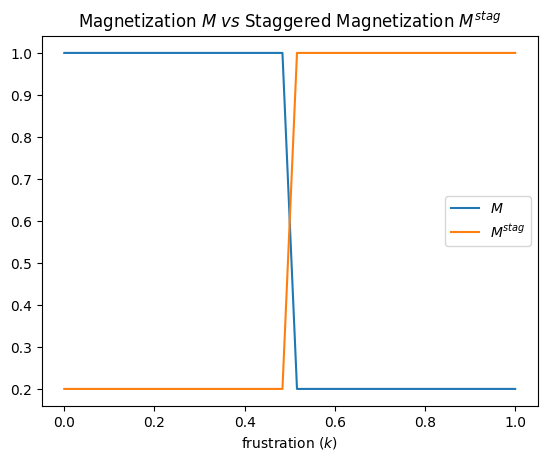

In [24]:
plt.plot(grid,mag,label="$M$")
plt.plot(grid,mag_st,label="$M^{stag}$")
plt.title("Magnetization $M$ $vs$ Staggered Magnetization $M^{stag}$")
plt.xlabel("frustration $(k)$")
plt.legend()

### Sparse

In [45]:
grid = np.linspace(0,1,32)
L = 16
long_pauli = "X"
trans_pauli = "Z"
M = magnetization(L=L, op=long_pauli)
M_st = stag_mag(L=L, op=long_pauli)
init = True

if init:
    if long_pauli == "X":
        val = (1/np.sqrt(2))**L
        v0 = np.full(2**L, val)
    elif long_pauli == "Z":
        v0 = np.zeros(2**L)
        v0[0] = 1    
    print("initialized...")
    mag_sp = []
    mag_st_sp = []
    eig_vals_sp = []
else:
    v0 = None
    print("no initial state...")
    mag_sp_no_init = []
    mag_st_sp_no_init = []
    eig_vals_sp_no_init = []

for k in grid:
    print(f"k: {k}")
    H = ANNNI(L=L,k=k,h=0,eps=1e-5, long=long_pauli, trans=trans_pauli, deg_method=2)
    e,v = spla.eigsh(H, k=1, v0=v0, which="SA")
    gs = v[:,0]
    if init:
        eig_vals_sp.append(e[0])
        mag_sp.append((gs.conjugate().T @ M @ gs).real)
        mag_st_sp.append((gs.conjugate().T @ M_st @ gs).real)
    else:
        eig_vals_sp_no_init.append(e[0])
        mag_sp_no_init.append((gs.conjugate().T @ M @ gs).real)
        mag_st_sp_no_init.append((gs.conjugate().T @ M_st @ gs).real)
    v0 = gs

initialized...
k: 0.0
k: 0.03225806451612903
k: 0.06451612903225806
k: 0.0967741935483871
k: 0.12903225806451613
k: 0.16129032258064516
k: 0.1935483870967742
k: 0.22580645161290322
k: 0.25806451612903225
k: 0.29032258064516125
k: 0.3225806451612903
k: 0.3548387096774194
k: 0.3870967741935484
k: 0.4193548387096774
k: 0.45161290322580644
k: 0.4838709677419355
k: 0.5161290322580645
k: 0.5483870967741935
k: 0.5806451612903225
k: 0.6129032258064516
k: 0.6451612903225806
k: 0.6774193548387096
k: 0.7096774193548387
k: 0.7419354838709677
k: 0.7741935483870968
k: 0.8064516129032258
k: 0.8387096774193548
k: 0.8709677419354839
k: 0.9032258064516129
k: 0.9354838709677419
k: 0.967741935483871
k: 1.0


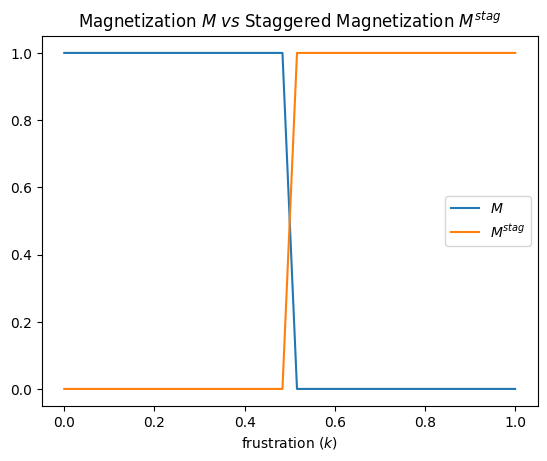

In [46]:
if init:
    # sparse with initial guess
    plt.plot(grid,mag_sp,label="$M$")
    plt.plot(grid,mag_st_sp,label="$M^{stag}$")
    plt.title("Magnetization $M$ $vs$ Staggered Magnetization $M^{stag}$")
    plt.xlabel("frustration $(k)$")
    plt.legend()
else:
    # sparse without initial guess
    plt.plot(grid,mag_sp_no_init,label="$M$")
    plt.plot(grid,mag_st_sp_no_init,label="$M^{stag}$")
    plt.title("Magnetization $M$ $vs$ Staggered Magnetization $M^{stag}$")
    plt.xlabel("frustration $(k)$")
    plt.legend()

Now, we can compare the results obtained with the three methods:
- Non-sparse diagonalization
- Sparse (IRAM) diagonalization with initial guess
- Sparse (IRAM) diagonalization **without** initial guess

We look at the energy $E$, magnetization $M$, and staggered magnetization $M^{stag}$

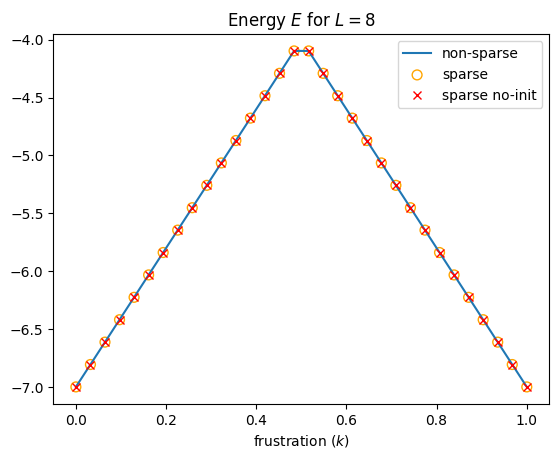

In [30]:
plt.plot(grid, eig_vals, label="non-sparse")
plt.scatter(grid, eig_vals_sp, marker="o", s=50, edgecolors="orange", facecolors="None", label="sparse")
plt.plot(grid, eig_vals_sp_no_init, "x", color="red", label="sparse no-init")
plt.title(f"Energy $E$ for $L={L}$")
plt.xlabel("frustration $(k)$")
plt.legend()
plt.savefig(f"results/figures/energy_exact_diag_different_methods_L_{L}.png")

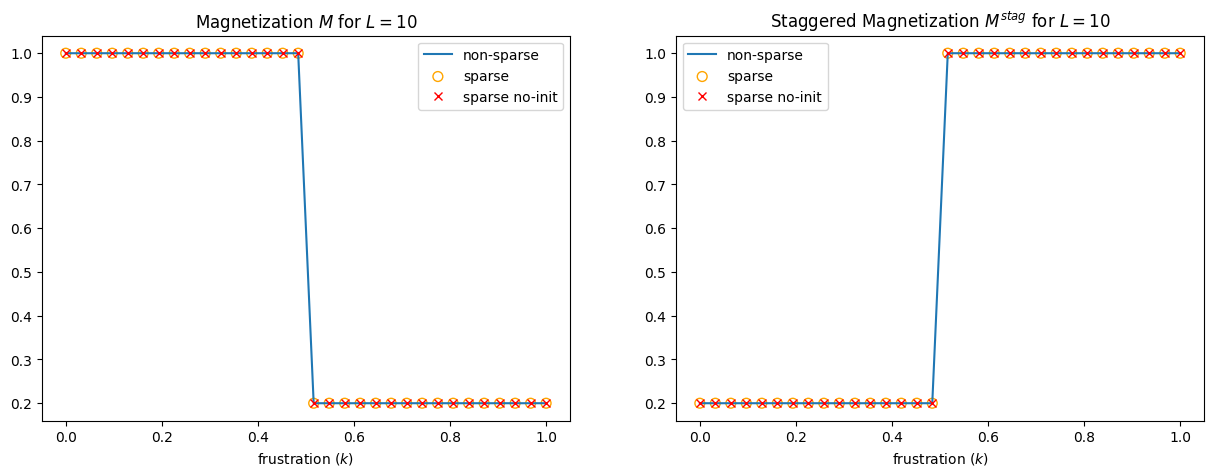

In [30]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
axs[0].plot(grid, mag, label="non-sparse")
axs[0].scatter(grid, mag_sp, marker="o", s=50, edgecolors="orange", facecolors="None", label="sparse")
axs[0].plot(grid, mag_sp_no_init, "x", color="red", label="sparse no-init")
axs[0].set_title(f"Magnetization $M$ for $L={L}$")
axs[0].set_xlabel("frustration $(k)$")
axs[0].legend()

axs[1].plot(grid, mag_st, label="non-sparse")
axs[1].scatter(grid, mag_st_sp, marker="o", s=50, edgecolors="orange", facecolors="None", label="sparse")
axs[1].plot(grid, mag_st_sp_no_init, "x", color="red", label="sparse no-init")
axs[1].set_title("Staggered Magnetization $M^{stag}$" + f" for $L={L}$")
axs[1].set_xlabel("frustration $(k)$")
axs[1].legend()
fig.savefig(f"results/figures/mag_vs_stag_mag_exact_diag_different_methods_L_{L}.png")

### Taking a MPS from a vector

In [5]:
grid = np.linspace(0,1,32)
L = 8
long_pauli = "X"
trans_pauli = "Z"
v0 = np.full(2**L, (1/np.sqrt(2))**L)
H = ANNNI(L=L,k=0,h=0,eps=1e-5, long=long_pauli, trans=trans_pauli)
e,v = la.eigh(H.toarray())
gs = v[:,0]
e_sp,v_sp = spla.eigsh(H, k=1, v0=v0, which="SA")
gs_sp = v_sp[:,0]
print(gs[0])
print(gs_sp[0])

(-0.06250000000703029-0j)
(0.0625+0j)


In [6]:
from qs_mps.utils import truncation
def vector_to_mps(vec: np.ndarray, trunc_chi: bool=True, trunc_tol: bool=False, chi: int=1, schmidt_tol: float=1e-15):
    """
    vector_to_mps

    We decompose the vector with successive svd starting from the right towards the left,
    hence a left sweep. The final tensors will be in Right Canonical Form (RCF)
    
    vec: np.ndarray - vector we want to transform in a MPS

    """
    vec_legs = int(np.log2(len(vec)))
    sites = []
    bonds = []
    alpha = 1
    for i in range(vec_legs):
        matrix = vec.reshape((2**(vec_legs-(i+1)),2*alpha))
        u,s,v = la.svd(matrix, full_matrices=False)
        bond_r = v.shape[1] // 2
        v = truncation(v, threshold=1e-15)
        s = truncation(s, threshold=1e-15)
        u = truncation(u, threshold=1e-15)
        v = v.reshape((v.shape[0], 2, bond_r))
        if trunc_chi:
            if v.shape[0] > chi:
                v = v[: chi, :, :]
                s = s[: chi]
                u = u[:, : chi]
                s = s / np.linalg.norm(s)
        if trunc_tol:
            condition = s >= schmidt_tol
            s_trunc = np.extract(condition, s)
            s = s_trunc / np.linalg.norm(s_trunc)
            v = v[: len(s), :, :]
            u = u[:, : len(s)]

        sites.append(v)
        bonds.append(s)
        vec = u @ np.diag(s)
        alpha = vec.shape[1]
    
    sites.reverse()
    bonds.reverse()
    return sites, bonds

In [14]:
mps, schmidt_list = vector_to_mps(gs, chi=16)
print([[site.shape, site] for site in mps])
print([[val.shape, val] for val in schmidt_list])

[[(1, 2, 2), array([[[-7.07106781e-01+0.j, -7.95427764e-11+0.j],
        [-7.07106781e-01+0.j,  7.95427764e-11+0.j]]])], [(2, 2, 4), array([[[ 7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j],
        [ 7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j]],

       [[-2.71414129e-06+0.j, -7.07105290e-01+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j],
        [ 2.71414129e-06+0.j,  7.07108272e-01+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j]]])], [(4, 2, 8), array([[[ 7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j],
        [ 7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j,  0.00000000e+00+0.j]],

       [[ 2.96600974e-06+0.j,  7.07105477e-

## DMRG ground state search

In [39]:
L = 8
chi = 16
path_tensor = "/Users/fradm98/Desktop/projects/2_ANNNI"

h_i = 0.0
h_f = 1.0
npoints = 32
grid = np.linspace(h_i,h_f,npoints)
precision = get_precision(num=(h_f-h_i)/npoints)
args_mps = {
            "L": L,
            "d": 2,
            "chi": chi,
            "type_shape": "rectangular",
            "model": "ANNNI",
            "trunc_tol": False,
            "trunc_chi": True,
            "where": L//2,
            "bond": True,
            "path": path_tensor,
            "save": True,
            "precision": precision,
            "eps": 1e-1,
        }

In [40]:
init_state = np.full((1, 2, 1), (1/np.sqrt(2))+args_mps['eps'])
init_tensor = [init_state for _ in range(L)]
h = 0.0
mag_dmrg = []
entropy_tot = []
schmidt = []
mag = magnetization(L=L)
op = np.array([[0,1],[1,0]])
for k in grid:
    precision = args_mps["precision"]
    chain = MPS(
        L=args_mps["L"],
        d=args_mps["d"],
        model=args_mps["model"],
        chi=args_mps["chi"],
        h=h,
        J=1,
        k=k,
        eps=args_mps["eps"],
    )
    # chain.sites = init_tensor
    # print(chain.sites[0], init_tensor[0])
    # chain.order_param(op=op)
    # m = chain.mpo_first_moment().real/L
    # print("===============================")
    # print(m)
    # print("===============================")

    # if k == 0:
    #     chain.enlarge_chi(type_shape="rectangular", prnt=False)
    
    chain._random_state(seed=7, chi=args_mps["chi"], type_shape=args_mps["type_shape"])
    chain.canonical_form(trunc_chi=args_mps["trunc_chi"], trunc_tol=args_mps["trunc_tol"])

    energy, entropy, schmidt_vals = chain.DMRG(
        trunc_tol=args_mps["trunc_tol"],
        trunc_chi=args_mps["trunc_chi"],
        where=args_mps["where"],
        bond=args_mps["bond"],
        long="X",
        trans="Z",
        n_sweeps=6,
    )
    print(chain.sites[0])
    init_tensor = chain.sites.copy()

    print(f"energy of h:{h:.{precision}f}, k:{k:.{precision}f} is:\n {energy}")
    print(f"Schmidt values in the middle of the chain:\n {schmidt_vals}")
    chain.order_param(op=op)
    m = chain.mpo_first_moment().real/L
    mag_dmrg.append(m)

    entropy_tot.append(entropy)
    schmidt.append(schmidt_vals[0][-1])
    # psi_dmrg = mps_to_vector(chain.sites)
    # mag_psi.append((psi_dmrg.conjugate().T @ mag @ psi_dmrg).real)


    print("===============================")
    print(m)
    print("===============================")

    # chain.save_sites(path=args_mps["path"], precision=args_mps["precision"])

Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 15
total time: 0.12615179599993098
##############################
[[[ 0.54227815+0.j -0.45379996+0.j]
  [ 0.54227815+0.j  0.45379996+0.j]]]
energy of h:0.00, k:0.00 is:
 [-6.9921652006896595, -6.9932061253415805, -6.995520203087973, 7.200000000000022, 7.200000000000003, 7.200000000000011, 7.200000000000005, 7.2, 7.200000000000013, 7.20000000000001, 7.200000000000051, 7.200000000000006, 7.200000000000016, 7.1999999999999975]
Schmidt values in the middle of the chain:
 [array([0.73581169, 0.6771862 , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])]
-3.0814879110195774e-32
Sweep n: 0

Sweep n: 1



/Users/fradm98/Desktop/fidelity-phase-tran/env/lib/python3.9/site-packages/qs_mps/utils.py:380: RuntimeWarning: divide by zero encountered in log2
  return -np.sum((s**2) * np.log2(s**2))
/Users/fradm98/Desktop/fidelity-phase-tran/env/lib/python3.9/site-packages/qs_mps/utils.py:380: RuntimeWarning: invalid value encountered in multiply
  return -np.sum((s**2) * np.log2(s**2))


##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 15
total time: 0.1363028989999293
##############################
[[[-0.68297976+0.j -0.1831356 +0.j]
  [ 0.68297976+0.j -0.1831356 +0.j]]]
energy of h:0.00, k:0.03 is:
 [-6.767614480359621, -6.770412269726149, -6.771064804198875, 7.393548387096795, 7.3935483870967715, 7.393548387096773, 7.3935483870967795, 7.393548387096773, 7.393548387096778, 7.39354838709681, 7.393548387096797, 7.393548387096794, 7.393548387096775, 7.3935483870967715]
Schmidt values in the middle of the chain:
 [array([0.89452695, 0.44701401, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])]
1.895649639576303e-17
Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an 

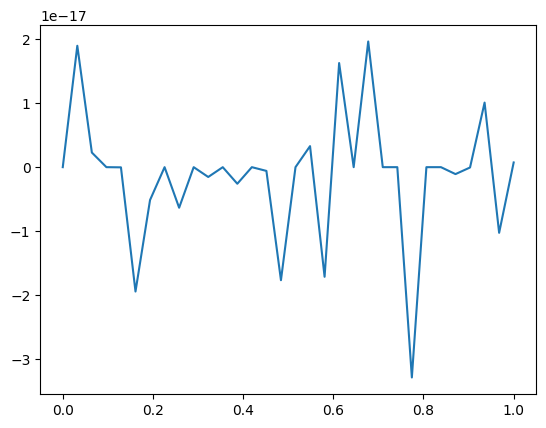

In [41]:
# mag_dmrg = []
# op = np.array([[0,1],[1,0]])
# # op = np.array([[1,0],[0,-1]])
# for k in grid:
#     mps = MPS(L=L, d=2, model="ANNNI", chi=chi, h=0, k=k, J=1, eps=args_mps["eps"])
#     mps.load_sites(path=path_tensor, precision=precision)
#     mps.order_param(op=op)
#     m = mps.mpo_first_moment().real/L
#     mag_dmrg.append(m)

plt.plot(grid,mag_dmrg)

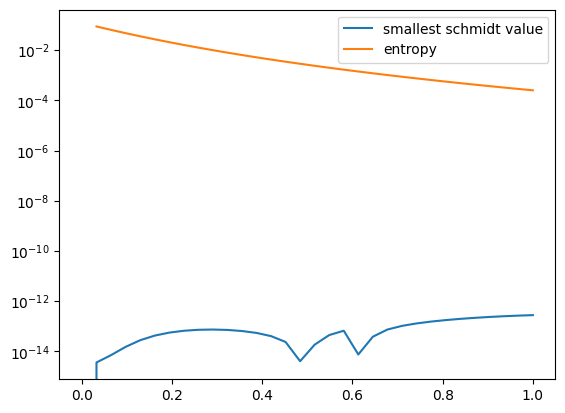

In [17]:
plt.plot(grid, schmidt, label="smallest schmidt value")
plt.plot(grid, entropy_tot, label="entropy")
plt.yscale('log')
plt.legend()

Sweep n: 0

Sweep n: 1

##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 39
total time: 0.16989486099919304
##############################
energy of h:0.10, k:0.00 is:
 [-19.00498757036305, -19.00750459404439, -19.010006301197365, -19.012507909333152, -19.015009562373606, -19.01751131375838, -19.020013276980546, -19.022515699114674, -19.02501912211653, -19.027524745340447, -19.030035251401593, -19.032556719220178, -19.035103149525096, -19.03770746464572, -19.040449224616918, -19.043528003049182, -19.04747193661925, -19.054460705169063, -19.05446070516903, -19.054460705169046, -19.05446070516902, -19.054460705169053, -19.054460705169095, -19.054460705169006, -19.05446070516907, -19.054460705169213, -19.054460705169223, -19.0544607051693, -19.05446070516947, -19.054460705169575, -19.05446070516976, -19.05446070516988, -19.054460705170083, -19.05446070517028, -19.054460705170463, -19.054

/Users/fradm98/Desktop/fidelity-phase-tran/env/lib/python3.9/site-packages/qs_mps/mps_class.py:403: ComplexWarning: Casting complex values to real discards the imaginary part
  extended_array[i][: shape[0], : shape[1], : shape[2]] = self.sites[i]


##############################
The energy between the two last updated states converged
to an order of 1e-10 after:
1 sweeps at site 2
total iterations 39
total time: 0.2807264139992185
##############################
energy of h:0.10, k:0.00 is:
 [-3.1379005167108622, -4.767398118562943, -5.198948898817486, -5.212393658927701, -7.122691697861516, -8.800752615946317, -8.924495738365758, -9.026273690004786, -9.596358356435243, -12.79135533497282, -12.915647480203035, -13.00589113083868, -13.581261841654664, -16.81475539508111, -16.831034227310496, -16.916188650782896, -18.312129317438377, -18.414976766709714, -18.414976766709692, -18.41497676670972, -18.414976766709692, -18.414976766709742, -18.414976766709724, -18.414976766709753, -18.41497676670967, -18.41497676670972, -18.414976766709824, -18.41497676670983, -18.414976766709838, -18.414976766709874, -18.414976766709923, -18.414976766710037, -18.41497676671003, -18.414976766709987, -18.655731464905735, -18.655731464905852, -18.65573146

<function matplotlib.pyplot.show(close=None, block=None)>

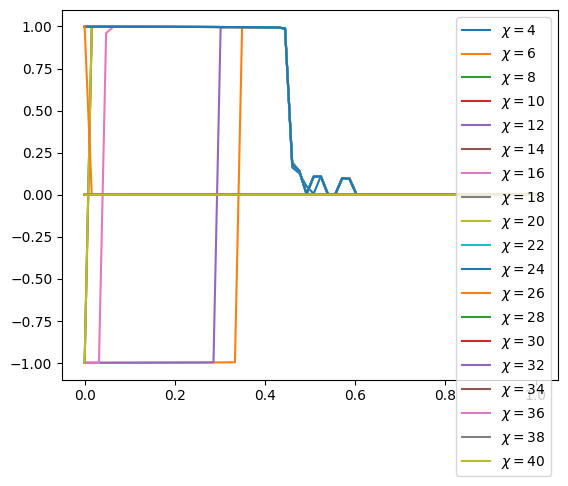

In [146]:
chis = [4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40]
init_state = np.full((1, 2, 1), (1/np.sqrt(2)))
init_tensor = [init_state for _ in range(L)]
h = 0.1
entropy_tot = []
mag_dmrg = []
schmidt = []
mag = magnetization(L=L)
op = np.array([[0,1],[1,0]])
for chi in chis:
    mag_dmrg_chi = []
    entropy_chi = []
    schmidt_chi = []
    for k in grid:
        precision = args_mps["precision"]
        chain = MPS(
            L=args_mps["L"],
            d=args_mps["d"],
            model=args_mps["model"],
            chi=chi,
            h=h,
            J=1,
            k=k,
            eps=args_mps["eps"],
        )
        chain.sites = init_tensor
        if k == 0:
            chain.enlarge_chi(type_shape="rectangular", prnt=False)
        
        # chain._random_state(seed=7, chi=args_mps["chi"], type_shape=args_mps["type_shape"])
        chain.canonical_form(trunc_chi=args_mps["trunc_chi"], trunc_tol=args_mps["trunc_tol"])

        energy, entropy, schmidt_vals = chain.DMRG(
            trunc_tol=args_mps["trunc_tol"],
            trunc_chi=args_mps["trunc_chi"],
            where=args_mps["where"],
            bond=args_mps["bond"],
            long="X",
            trans="Z",
            n_sweeps=6,
        )
        init_tensor = chain.sites.copy()

        print(f"energy of h:{h:.{precision}f}, k:{k:.{precision}f} is:\n {energy}")
        print(f"Schmidt values in the middle of the chain:\n {schmidt_vals}")
        chain.order_param(op=op)
        m = chain.mpo_first_moment().real/L
        mag_dmrg_chi.append(m)

        entropy_chi.append(entropy)
        schmidt_chi.append(schmidt_vals[0][-1])

        print("===============================")
        print(m)
        print("===============================")

    entropy_tot.append(entropy_chi)
    schmidt.append(schmidt_chi)
    mag_dmrg.append(mag_dmrg_chi)
    plt.plot(grid,mag_dmrg_chi, label=f"$\chi={chi}$")
plt.legend()
plt.show

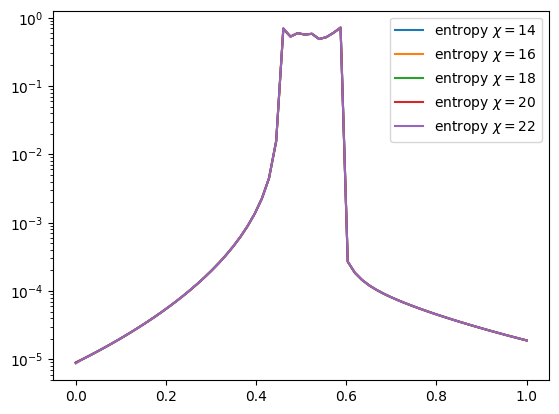

In [143]:
# plt.plot(grid, schmidt, label="smallest schmidt value")
for entr, chi in zip(entropy_tot[5:10], chis[5:10]):
    plt.plot(grid, entr, label=f"entropy $\chi={chi}$")
plt.yscale('log')
plt.legend()

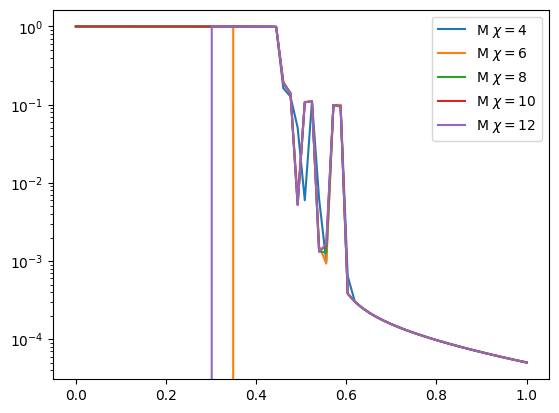

In [148]:
for mag, chi in zip(mag_dmrg[:5], chis[:5]):
    plt.plot(grid, mag, label=f"M $\chi={chi}$")
plt.yscale('log')
plt.legend()

# Reduced Density Matrices with SparseED

In [53]:
grid = np.linspace(0,1,32)
L = 8
long_pauli = "X"
trans_pauli = "Z"
M = magnetization(L=L, op=long_pauli)
M_st = stag_mag(L=L, op=long_pauli)
init = True

if init:
    if long_pauli == "X":
        val = (1/np.sqrt(2))**L
        v0 = np.full(2**L, val)
    elif long_pauli == "Z":
        v0 = np.zeros(2**L)
        v0[0] = 1    
    print("initialized...")
    mag_sp = []
    mag_st_sp = []
    eig_vals_sp = []
else:
    v0 = None
    print("no initial state...")
    mag_sp_no_init = []
    mag_st_sp_no_init = []
    eig_vals_sp_no_init = []

vecs = []
for h in grid:
    vecs_h = []
    for k in grid:
        print(f"h: {h}, k: {k}")
        H = ANNNI(L=L,k=k,h=h,eps=1e-5, long=long_pauli, trans=trans_pauli, deg_method=1)
        e,v = spla.eigsh(H, k=1, v0=v0, which="SA")
        gs = v[:,0]
        if init:
            eig_vals_sp.append(e[0])
            mag_sp.append((gs.conjugate().T @ M @ gs).real)
            mag_st_sp.append((gs.conjugate().T @ M_st @ gs).real)
        else:
            eig_vals_sp_no_init.append(e[0])
            mag_sp_no_init.append((gs.conjugate().T @ M @ gs).real)
            mag_st_sp_no_init.append((gs.conjugate().T @ M_st @ gs).real)
        v0 = gs

        # Define the subsystems you want to calculate the reduced density matrices for
        subsystem_B_indices = [d for d in range(L)]  # Indices of qubits in subsystem B
        subsystem_A_indices = [subsystem_B_indices.pop(L//2)]
        print(subsystem_A_indices, subsystem_B_indices)
          # Indices of qubits in subsystem B

        # Calculate the reduced density matrices
        dims = [2] * len(gs)  # Dimension of each qubit
        print(dims)
        dims_A = [dims[i] for i in subsystem_B_indices]  # Dimension of subsystem A
        print(dims_A)

        # Calculate the reduced density matrix of subsystem A
        rho_A = np.reshape(gs, dims) #.sum(axis=tuple(subsystem_B_indices)).reshape(dims_A * 2)

        vecs_h.append(gs)

    vecs.append(vecs_h)

initialized...
h: 0.0, k: 0.0
[4] [0, 1, 2, 3, 5, 6, 7]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[2, 2, 2, 2, 2, 2, 2]


ValueError: maximum supported dimension for an ndarray is 32, found 256